# Virtual Analog Distortion

Virtual analog distortion emulates the nonlinear behaviour of electronic circuits using purely digital transfer curves. The two functions here model complementary types of analog saturation:

| Function | Description |
| --- | --- |
| `diode_clip` | Asymmetric soft-clipping modelling a series diode circuit. The positive half-cycle clips at a lower threshold than the negative half-cycle (asymmetric transfer curve), producing both **odd and even harmonics** — characteristically "buzzy" guitar-pedal distortion. |
| `analog_saturate` | Symmetric 3rd-order polynomial soft saturation: `y = 3x/2 · (1 − x²/3)` (scaled). Approximates a triode vacuum tube in its operating region. Produces **odd harmonics only** (3rd, 5th, …) — classic "warm" tube character. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.virtual_analog import analog_saturate, diode_clip

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Transfer curves, clipped waveforms, and harmonic spectra for both distortion models applied to a 440 Hz sine.

**2 × 4 grid:**

**Top row — diode_clip, three threshold values (1.0 / 0.7 / 0.4):**
- **Transfer curve:** asymmetric S-shape; the positive half saturates more aggressively than the negative half — characteristic of a forward-biased diode
- **Waveform:** visible asymmetry; positive peaks are more rounded/clipped than negative peaks
- **Spectrum:** both **odd and even harmonics** (2nd, 3rd, 4th, …) present due to the asymmetry; the 2nd harmonic is a distinctive "diode signature"
- **Harmonic amplitude vs order:** decays unevenly; even harmonics are at a similar level to odd ones

**Bottom row — analog_saturate, three drive values (1 / 3 / 8):**
- **Transfer curve:** smooth symmetric cubic S-curve; no asymmetry
- **Waveform:** symmetrically rounded peaks; no asymmetric distortion
- **Spectrum:** only **odd harmonics** (3rd, 5th, 7th); even harmonics are absent — this is the mathematical consequence of any odd (symmetric) transfer function applied to a sine
- **Harmonic amplitude vs order:** decays rapidly; 3rd harmonic dominates; very "tube-like" warmth

Asymmetric (even harmonic) distortion is characteristic of diodes and class-B push-pull amplifiers; symmetric (odd harmonic) distortion is characteristic of triode tubes and class-A amplifiers.


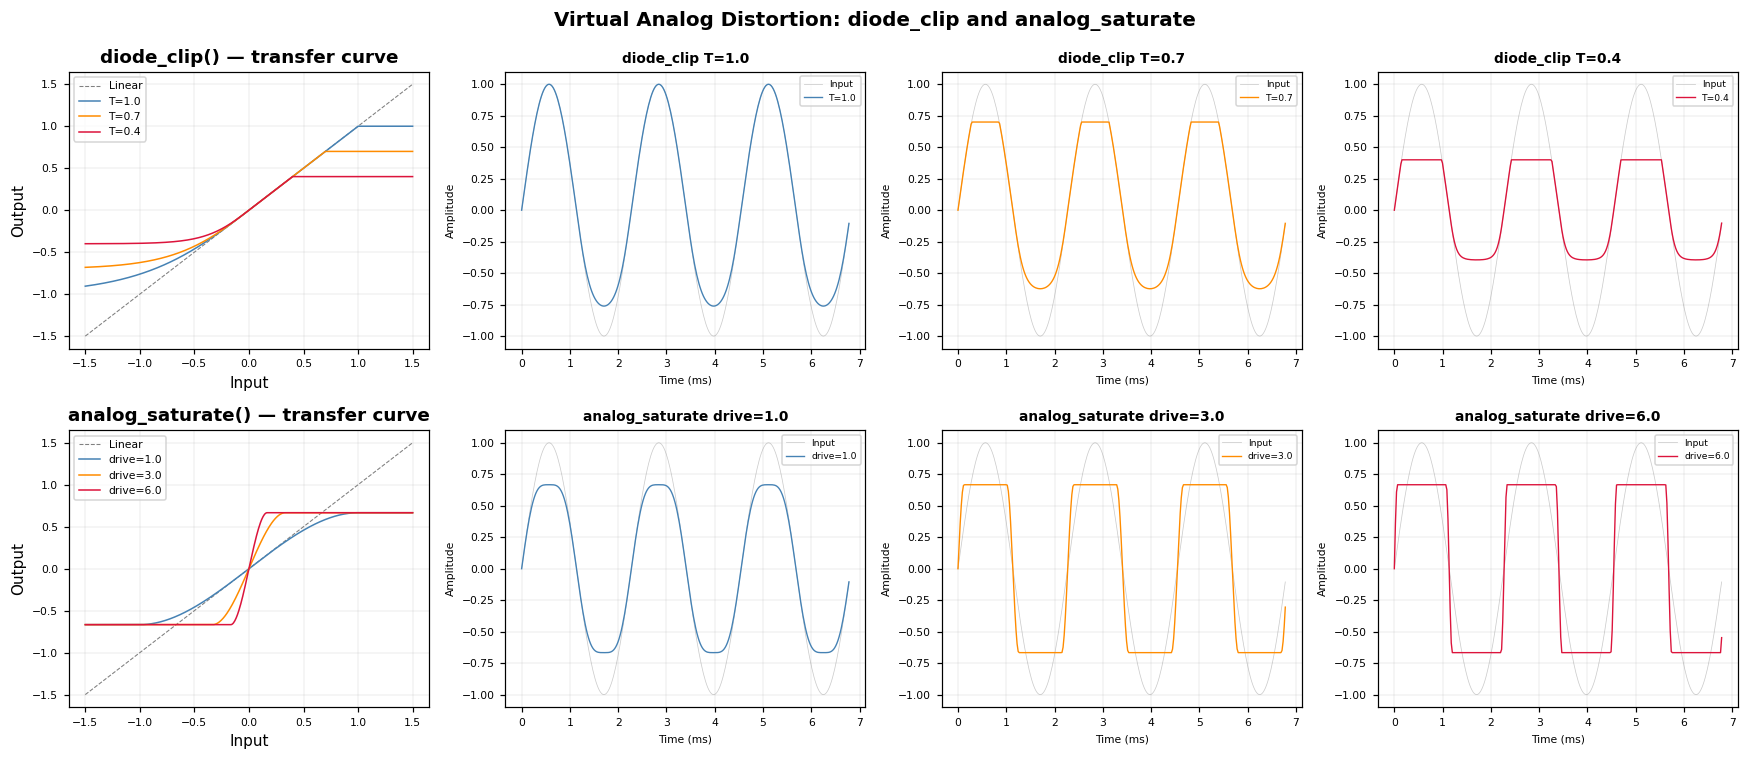

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000
x_tc = np.linspace(-1.5, 1.5, 500)

COLORS = ["steelblue", "darkorange", "crimson"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Transfer curves
ax = axes[0, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.7, linestyle="--", label="Linear")
for thresh, color in zip([1.0, 0.7, 0.4], COLORS):
    ax.plot(x_tc, diode_clip(x_tc, threshold=thresh), color=color, linewidth=1.0, label=f"T={thresh}")
ax.set_title("diode_clip() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

ax = axes[1, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.7, linestyle="--", label="Linear")
for drive, color in zip([1.0, 3.0, 6.0], COLORS):
    ax.plot(x_tc, analog_saturate(x_tc * drive / drive, drive=drive), color=color, linewidth=1.0, label=f"drive={drive}")
ax.set_title("analog_saturate() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

# Waveforms
THRESHOLDS = [1.0, 0.7, 0.4]
DRIVES = [1.0, 3.0, 6.0]

for col, (thresh, color) in enumerate(zip(THRESHOLDS, COLORS), start=1):
    out = diode_clip(sig, threshold=thresh)
    axes[0, col].plot(t_ms, sig, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    axes[0, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"T={thresh}")
    axes[0, col].set_title(f"diode_clip T={thresh}", fontsize=9, fontweight="bold")
    axes[0, col].legend(fontsize=6)
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)

for col, (drive, color) in enumerate(zip(DRIVES, COLORS), start=1):
    out = analog_saturate(sig, drive=drive)
    axes[1, col].plot(t_ms, sig, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    axes[1, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"drive={drive}")
    axes[1, col].set_title(f"analog_saturate drive={drive}", fontsize=9, fontweight="bold")
    axes[1, col].legend(fontsize=6)
    axes[1, col].set_xlabel("Time (ms)", fontsize=7)
    axes[1, col].set_ylabel("Amplitude", fontsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Virtual Analog Distortion: diode_clip and analog_saturate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Distortion is best understood by ear. A sawtooth at 220 Hz driven into diode clipping and tube saturation — two different flavours of harmonic enrichment.

| Effect | Character |
| --- | --- |
| Diode clip | Hard symmetric clipping — aggressive, square-wave-like |
| Tube saturation | Soft asymmetric saturation — warmer, smoother odd harmonics |


In [3]:
from IPython.display import Audio, display

DUR_A = 2.0
N_A   = int(FS * DUR_A)
t_a   = np.arange(N_A) / FS
saw_a = 0.8 * (2 * ((220.0 * t_a) % 1.0) - 1.0)

diode_a = diode_clip(saw_a, threshold=0.4)
tube_a  = analog_saturate(saw_a, drive=5.0)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Clean sawtooth at 220 Hz")
display(Audio(norm(saw_a), rate=FS))
print("Diode clipping (threshold=0.4) — aggressive hard clipping, rich odd harmonics")
display(Audio(norm(diode_a), rate=FS))
print("Tube saturation (drive=5.0) — soft asymmetric saturation, warmer character")
display(Audio(norm(tube_a), rate=FS))

Clean sawtooth at 220 Hz


Diode clipping (threshold=0.4) — aggressive hard clipping, rich odd harmonics


Tube saturation (drive=5.0) — soft asymmetric saturation, warmer character


## Wavefolder

A wavefolder reflects the signal back each time it would exceed ±1, producing mirror images of the waveform rather than clipping it. Each fold crossing adds a new spectral partial, giving richer and more evenly distributed harmonic content than clipping.

| Gain | Behaviour |
| --- | --- |
| ≤ 1 | Signal stays within ±1 — no folding, output is a scaled sine |
| 2 | Peaks fold once per half-cycle — triangle-like at the tips |
| 4 | Peaks fold twice — increasingly complex waveform |

Wavefolding is the defining nonlinearity of the **Buchla 259** Complex Waveform Generator and the Serge Wave Multiplier. Unlike clipping, which crushes the peak, folding adds new spectral components each time a boundary is crossed — the harmonic series grows with gain rather than converging to a square wave.


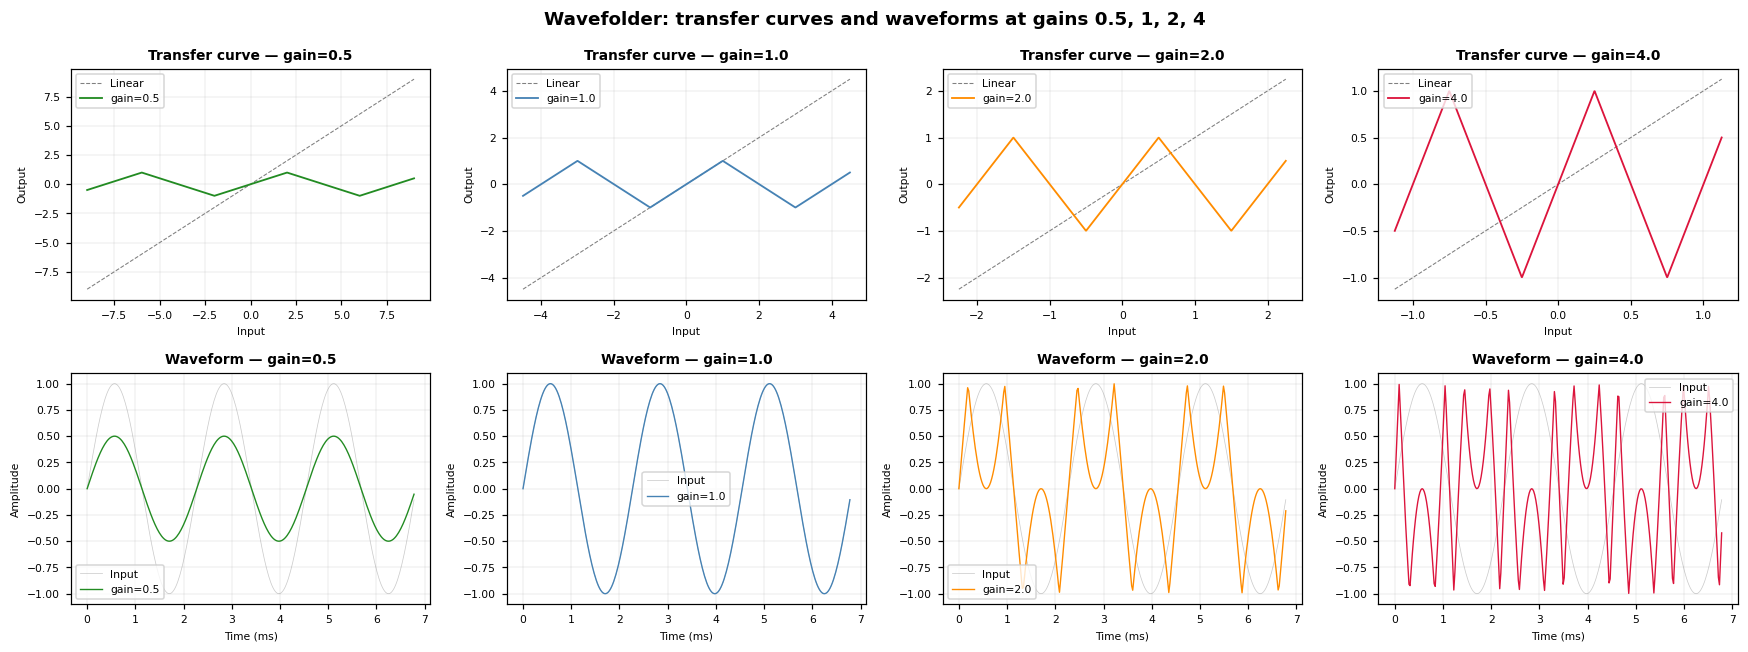

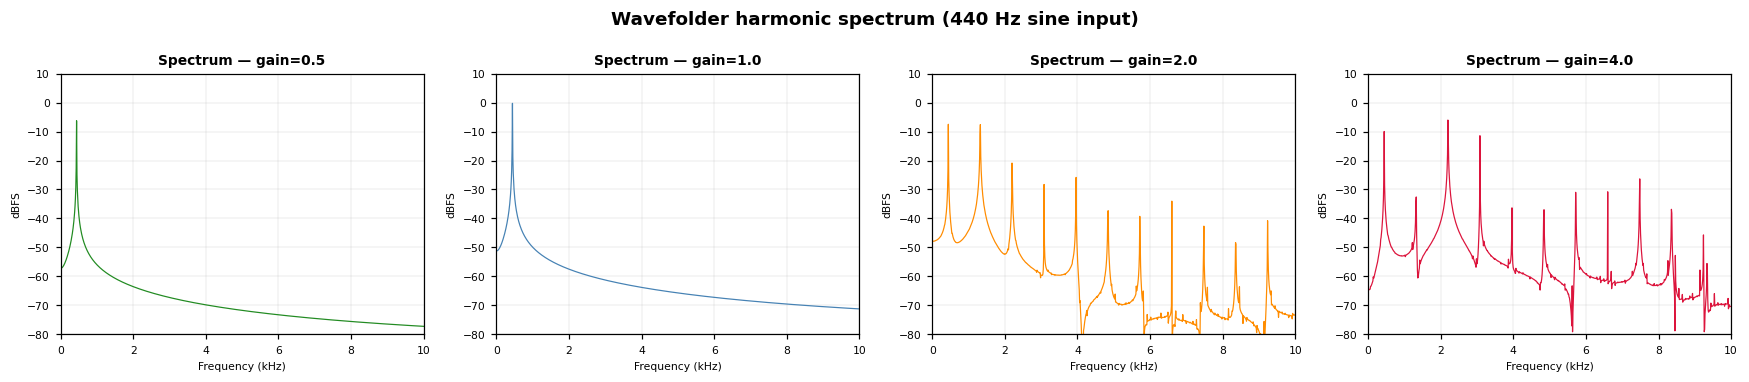

In [4]:
from python.virtual_analog import wavefold

GAINS = [0.5, 1.0, 2.0, 4.0]
COLORS_WF = ["forestgreen", "steelblue", "darkorange", "crimson"]

FREQ_WF = 440.0
DURATION_WF = 3 / FREQ_WF
_, sig_wf = generate_sine(freq=FREQ_WF, fs=FS, duration=DURATION_WF)
t_ms_wf = np.arange(len(sig_wf)) / FS * 1000

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

x_tc = np.linspace(-4.5, 4.5, 1000)

for col, (gain, color) in enumerate(zip(GAINS, COLORS_WF)):
    # Transfer curve (input normalised to [-1,1] range for display)
    ax = axes[0, col]
    inp_norm = x_tc / max(gain, 0.5)
    ax.plot(inp_norm, inp_norm, color="gray", linewidth=0.7, linestyle="--", label="Linear")
    ax.plot(inp_norm, wavefold(inp_norm, gain=gain), color=color, linewidth=1.2, label=f"gain={gain}")
    ax.set_title(f"Transfer curve — gain={gain}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Input", fontsize=7)
    ax.set_ylabel("Output", fontsize=7)
    ax.legend(fontsize=7)

    # Waveform
    ax = axes[1, col]
    out_wf = wavefold(sig_wf, gain=gain)
    ax.plot(t_ms_wf, sig_wf, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    ax.plot(t_ms_wf, out_wf, color=color, linewidth=0.9, label=f"gain={gain}")
    ax.set_title(f"Waveform — gain={gain}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Time (ms)", fontsize=7)
    ax.set_ylabel("Amplitude", fontsize=7)
    ax.legend(fontsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Wavefolder: transfer curves and waveforms at gains 0.5, 1, 2, 4", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Harmonic spectrum comparison
fig2, axes2 = plt.subplots(1, 4, figsize=(16, 3.5))
N_spec = 4096
t_spec = np.arange(N_spec) / FS
sig_spec = np.sin(2 * np.pi * FREQ_WF * t_spec)
freqs_spec = np.fft.rfftfreq(N_spec, d=1.0/FS)

for col, (gain, color) in enumerate(zip(GAINS, COLORS_WF)):
    sp = 20 * np.log10(np.abs(np.fft.rfft(wavefold(sig_spec, gain=gain))) / N_spec * 2 + 1e-12)
    axes2[col].plot(freqs_spec / 1000, sp, color=color, linewidth=0.8)
    axes2[col].set_xlim(0, 10)
    axes2[col].set_ylim(-80, 10)
    axes2[col].set_title(f"Spectrum — gain={gain}", fontsize=9, fontweight="bold")
    axes2[col].set_xlabel("Frequency (kHz)", fontsize=7)
    axes2[col].set_ylabel("dBFS", fontsize=7)
    axes2[col].tick_params(labelsize=7)
    axes2[col].grid(True, linewidth=0.3, alpha=0.5)

fig2.suptitle("Wavefolder harmonic spectrum (440 Hz sine input)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Wavefolder Audio Examples

A sawtooth at 220 Hz through the wavefolder at increasing gain values. The character changes from clean → mildly folded → triangle-like → complex multi-fold timbre.

| Gain | Expected character |
| --- | --- |
| 0.5 | Clean, unfolded — quieter sawtooth |
| 1.0 | Barely folding at peaks — subtle brightening |
| 2.0 | One full fold per half-cycle — triangle-ish, brighter |
| 4.0 | Multiple folds — rich, Buchla-style metallic timbre |


In [5]:
from IPython.display import Audio, display

DUR_WF  = 2.0
N_WF    = int(FS * DUR_WF)
t_wf_a  = np.arange(N_WF) / FS
saw_wf  = 0.8 * (2 * ((220.0 * t_wf_a) % 1.0) - 1.0)

def norm(x):
    peak = np.max(np.abs(x))
    return x / peak * 0.7 if peak > 0 else x

print("Clean sawtooth at 220 Hz (input signal)")
display(Audio(norm(saw_wf), rate=FS))

for gain, label in [(0.5, "quiet, unfolded"),
                    (1.0, "barely folding at peaks — subtle brightening"),
                    (2.0, "one fold per half-cycle — triangle-ish timbre"),
                    (4.0, "multiple folds — Buchla-style metallic character")]:
    out = wavefold(saw_wf, gain=gain)
    print(f"wavefold gain={gain} — {label}")
    display(Audio(norm(out), rate=FS))


Clean sawtooth at 220 Hz (input signal)


wavefold gain=0.5 — quiet, unfolded


wavefold gain=1.0 — barely folding at peaks — subtle brightening


wavefold gain=2.0 — one fold per half-cycle — triangle-ish timbre


wavefold gain=4.0 — multiple folds — Buchla-style metallic character
